In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:
file_path = "country_wise_latest.csv"
df = pd.read_csv(file_path, on_bad_lines='skip')

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [ ]:
threshold = df['Deaths'].median()

df['Death_Class'] = (df['Deaths'] > threshold).astype(int)


In [ ]:
features = [
    'Confirmed', 'Recovered', 'Active',
    'New cases', 'New deaths', 'New recovered',
    'Deaths / 100 Cases', 'Recovered / 100 Cases',
    'Deaths / 100 Recovered', 'Confirmed last week',
    '1 week change', '1 week % increase'
]

X = df[features]
y = df['Death_Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

In [ ]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


===== Random Forest =====
Accuracy: 0.9459459459459459

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.94      0.94      0.94        18

    accuracy                           0.95        37
   macro avg       0.95      0.95      0.95        37
weighted avg       0.95      0.95      0.95        37



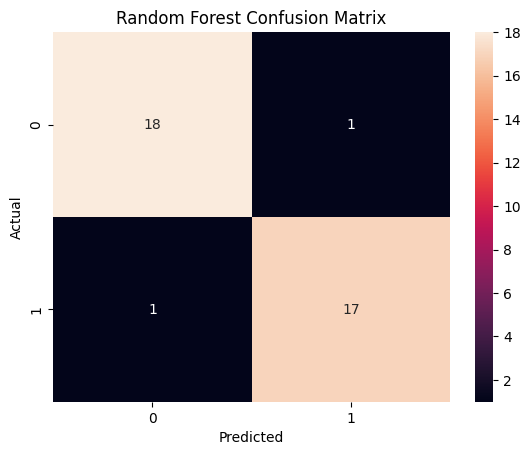


===== XGBoost =====
Accuracy: 0.9459459459459459

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.94      0.94      0.94        18

    accuracy                           0.95        37
   macro avg       0.95      0.95      0.95        37
weighted avg       0.95      0.95      0.95        37



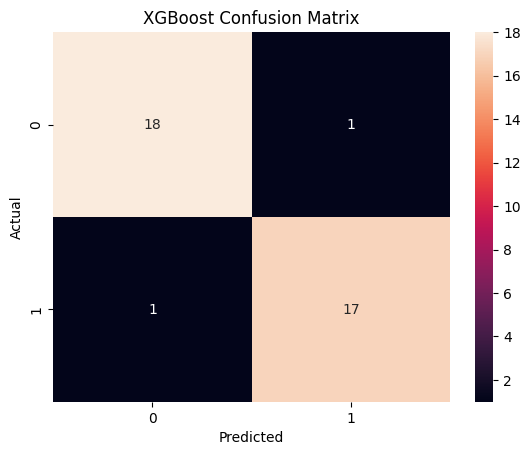

In [ ]:
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("XGBoost", y_test, xgb_pred)

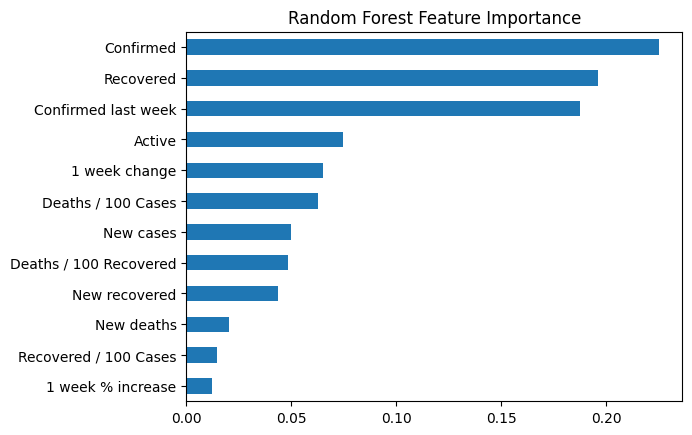

In [ ]:
feat_importance = pd.Series(rf_model.feature_importances_, index=features)

plt.figure()
feat_importance.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

**K-Means**

Elbow Method

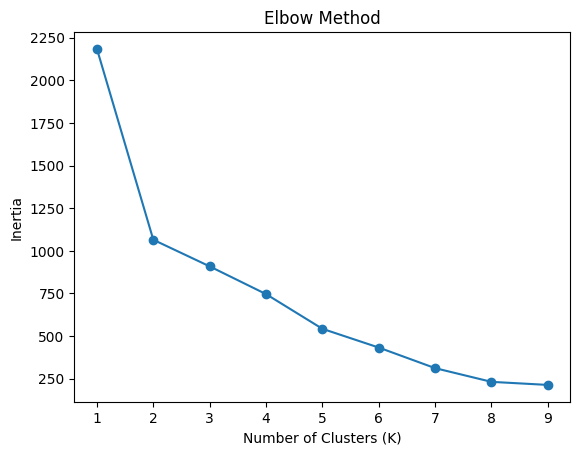

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

Apply K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

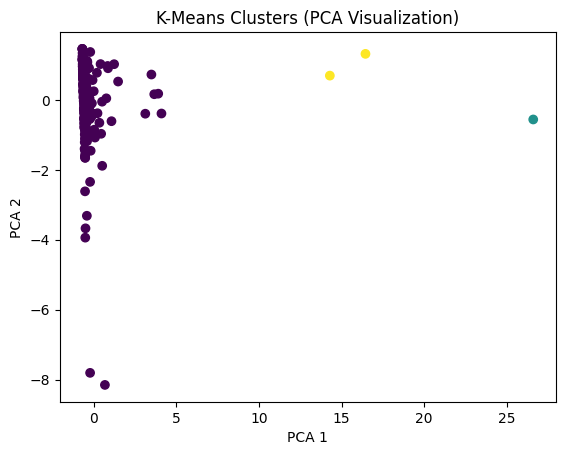

In [ ]:
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-Means Clusters (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nCluster Summary:\n", cluster_summary)


Cluster Summary:
             Confirmed     Recovered        Active     New cases   New deaths  \
Cluster                                                                        
0        4.494642e+04  2.985741e+04  1.302331e+04    575.804469    17.111732   
1        4.290259e+06  1.325804e+06  2.816444e+06  56336.000000  1076.000000   
2        1.961224e+06  1.398904e+06  5.018075e+05  33870.500000   625.500000   

         New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
Cluster                                                             
0           443.329609            2.970168               66.76352   
1         27941.000000            3.450000               30.90000   
2         33663.000000            2.925000               69.93500   

         Deaths / 100 Recovered  Confirmed last week  1 week change  \
Cluster                                                               
0                     41.129609         4.128887e+04    3657.553073   
1                    

**Neural Network**

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5172 - loss: 0.7276 - val_accuracy: 0.5172 - val_loss: 0.7965
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5690 - loss: 0.6715 - val_accuracy: 0.5862 - val_loss: 0.7132
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6034 - loss: 0.6466 - val_accuracy: 0.5862 - val_loss: 0.6586
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6034 - loss: 0.6282 - val_accuracy: 0.5862 - val_loss: 0.6228
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6121 - loss: 0.6192 - val_accuracy: 0.6552 - val_loss: 0.5930
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6293 - loss: 0.6051 - val_accuracy: 0.7241 - val_loss: 0.5691
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6293 - loss: 0.5980 - val_accuracy: 0.7241 - val_loss: 0.5456
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6466 - loss: 0.5882 - val_accuracy: 0.7586 - val_loss: 0.5304
Ep

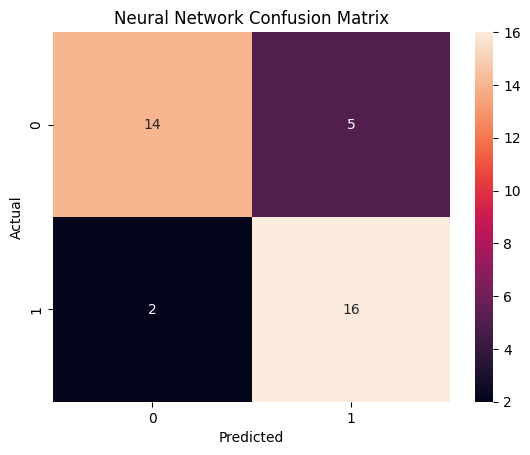

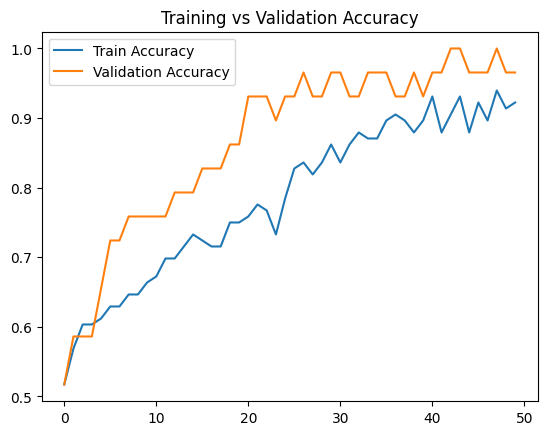

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

df = pd.read_csv("country_wise_latest.csv", on_bad_lines='skip')

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

threshold = df['Deaths'].median()
df['Death_Class'] = (df['Deaths'] > threshold).astype(int)

features = [
    'Confirmed', 'Recovered', 'Active',
    'New cases', 'New deaths', 'New recovered',
    'Deaths / 100 Cases', 'Recovered / 100 Cases',
    'Deaths / 100 Recovered', 'Confirmed last week',
    '1 week change', '1 week % increase'
]

X = df[features]
y = df['Death_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  SCALING (VERY IMPORTANT for NN)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#BUILD NEURAL NETWORK

model = Sequential()

# Input layer + Hidden layer 1
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Hidden layer 2
model.add(Dense(32, activation='relu'))

# Output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

#COMPILE MODEL
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

y_pred_prob = model.predict(X_test)

# Convert probabilities to 0/1
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()